In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
sns.set_style("whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("original.csv")
print("Shape:", df.shape)

Shape: (1537, 40)


In [2]:

df.columns=df.columns.str.replace('-', '_').str.replace('.', '_').str.lower()

In [3]:
df.head()

,gender,age,height,weight,bmi,l1_4,l1_4t,fn,fnt,tl,...,hyperuricemia,as,vt,vd,op,cad,ckd,fracture,smoking,drinking
0,2,61.9,164.0,47.0,17.474717,0.894,-2.4,0.6895,-2.95,0.7130,...,1,1,0,1,1,1,0,0,1,0
1,2,55.0,162.0,54.0,20.576132,1.333,1.3,0.9130,-1.30,1.0675,...,1,1,0,1,1,0,1,0,0,0
2,2,44.0,160.0,54.0,21.093750,1.157,-0.2,0.5190,-3.85,0.5770,...,1,1,0,1,1,1,0,0,0,0
3,1,64.7,158.0,59.0,23.634033,0.948,-2.3,0.7920,-2.15,0.9050,...,1,1,0,1,1,1,0,0,1,1
4,1,88.5,167.0,60.0,21.513859,1.114,-0.9,0.8250,-1.90,0.9385,...,1,1,0,1,1,1,0,0,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1537 non-null   int64  
 1   age              1501 non-null   float64
 2   height           1503 non-null   float64
 3   weight           1503 non-null   float64
 4   bmi              1503 non-null   float64
 5   l1_4             1537 non-null   float64
 6   l1_4t            1537 non-null   float64
 7   fn               1537 non-null   float64
 8   fnt              1537 non-null   float64
 9   tl               1537 non-null   float64
 10  tlt              1537 non-null   float64
 11  alt              1535 non-null   float64
 12  ast              1535 non-null   float64
 13  bun              1536 non-null   float64
 14  crea             1534 non-null   float64
 15  uric             1537 non-null   float64
 16  fbg              1521 non-null   float64
 17  hdl_c            1520 non

In [5]:
df.describe()

,gender,age,height,weight,bmi,l1_4,l1_4t,fn,fnt,tl,...,hyperuricemia,as,vt,vd,op,cad,ckd,fracture,smoking,drinking
count,1537.000000,1501.000000,1503.000000,1503.000000,1503.000000,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000,...,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000
mean,1.385166,59.852232,165.820692,67.151031,24.312817,1.136400,-0.551972,0.866763,-1.300755,0.934433,...,0.174366,0.749512,0.018868,0.072869,0.369551,0.202993,0.038386,0.020169,0.257645,0.227716
std,0.486793,12.940563,8.087217,11.991113,3.316477,0.187552,1.526073,0.145872,1.111612,0.153444,...,0.379547,0.433435,0.136103,0.260006,0.482840,0.402358,0.192190,0.140624,0.437480,0.419495
min,1.000000,28.600000,141.000000,23.000000,9.213267,0.763000,-3.500000,0.327500,-5.050000,0.308000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,51.000000,160.000000,59.000000,22.066075,0.999000,-1.600000,0.768500,-2.050000,0.835000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,57.000000,167.000000,67.000000,24.218750,1.124000,-0.700000,0.858500,-1.400000,0.926000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,67.300000,172.000000,75.000000,26.356049,1.256000,0.400000,0.965000,-0.550000,1.035500,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,2.000000,99.800000,187.000000,113.000000,37.261470,1.936000,6.000000,1.419000,2.700000,1.456500,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.isnull().sum()

gender              0
age                36
height             34
weight             34
bmi                34
l1_4                0
l1_4t               0
fn                  0
fnt                 0
tl                  0
tlt                 0
alt                 2
ast                 2
bun                 1
crea                3
uric                0
fbg                16
hdl_c              17
ldl_c              14
ca                  2
p                   5
mg                  3
calsium             0
calcitriol          0
bisphosphonate      0
calcitonin          0
htn                 0
copd                0
dm                  0
hyperlipidaemia     0
hyperuricemia       0
as                  0
vt                  0
vd                  0
op                  0
cad                 0
ckd                 0
fracture            0
smoking             0
drinking            0
dtype: int64

In [7]:
df.drop(columns=['l1_4','fn','tl'],inplace=True)

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

In [10]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer


imputer = IterativeImputer(random_state=42)


numerical_cols = ['age', 'height', 'weight','mg','p','ca','ldl_c','hdl_c','fbg','crea','bun','ast','alt']
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns



for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
   
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
   
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    percentage = (outlier_count / len(df)) * 100
    
    print(f"{col}': found {outlier_count} outliers ({percentage:.2f}%)")

print("\n--- Generating Visualizations ---")


num_plots = len(numeric_cols)
plt.figure(figsize=(10,8))


gender': found 0 outliers (0.00%)
age': found 16 outliers (1.04%)
height': found 1 outliers (0.07%)
weight': found 17 outliers (1.11%)
bmi': found 24 outliers (1.56%)
l1_4t': found 19 outliers (1.24%)
fnt': found 14 outliers (0.91%)
tlt': found 17 outliers (1.11%)
alt': found 83 outliers (5.40%)
ast': found 81 outliers (5.27%)
bun': found 71 outliers (4.62%)
crea': found 60 outliers (3.91%)
uric': found 19 outliers (1.24%)
fbg': found 121 outliers (7.88%)
hdl_c': found 42 outliers (2.73%)
ldl_c': found 11 outliers (0.72%)
ca': found 32 outliers (2.08%)
p': found 39 outliers (2.54%)
mg': found 28 outliers (1.82%)
calsium': found 226 outliers (14.71%)
calcitriol': found 263 outliers (17.12%)
bisphosphonate': found 94 outliers (6.12%)
calcitonin': found 88 outliers (5.73%)
htn': found 0 outliers (0.00%)
copd': found 378 outliers (24.61%)
dm': found 0 outliers (0.00%)
hyperlipidaemia': found 0 outliers (0.00%)
hyperuricemia': found 267 outliers (17.38%)
as': found 0 outliers (0.00%)
vt': f

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

--- Generating KDE Plots for all Continuous Float Columns ---


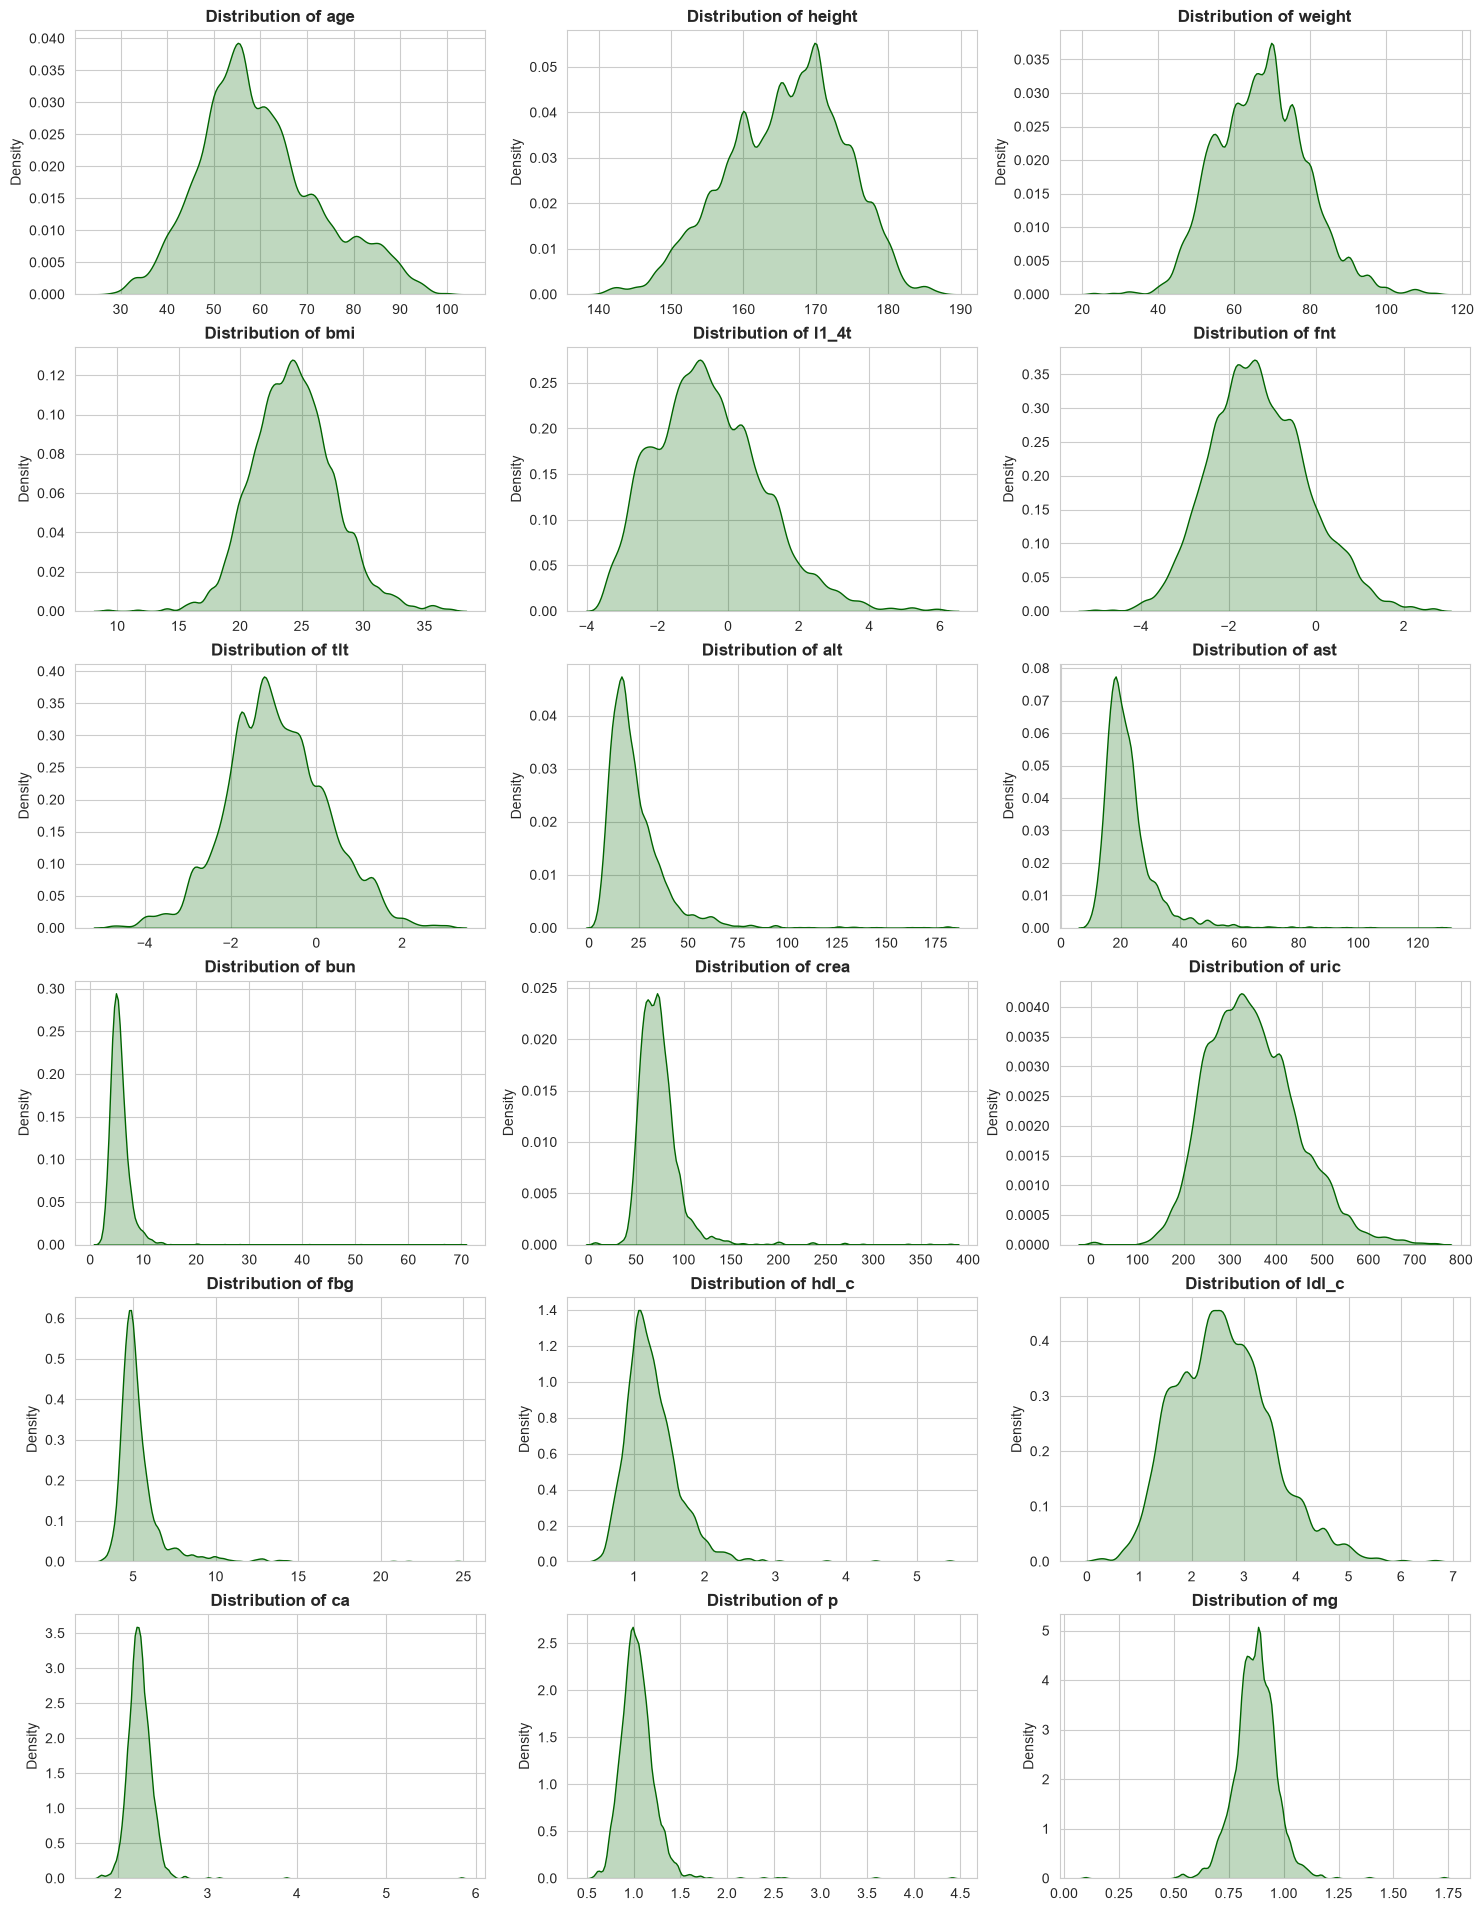

In [12]:
float_cols = df.select_dtypes(include=['float64']).columns.tolist()

n_cols = 3
n_rows = (len(float_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten() 

print("--- Generating KDE Plots for all Continuous Float Columns ---")
for i, col in enumerate(float_cols):
    sns.kdeplot(data=df, x=col, fill=True, color="darkgreen", ax=axes[i], bw_adjust=0.5)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

In [13]:

binary_cat_cols = [
    'gender', 'calsium', 'calcitriol', 'bisphosphonate', 'calcitonin',
    'htn', 'copd', 'dm', 'hyperlipidaemia', 'hyperuricemia', 'as', 'vt',
    'vd', 'op', 'cad', 'ckd', 'fracture', 'smoking', 'drinking'
]

continuous_cols = [c for c in df.columns if c not in binary_cat_cols]

for c in continuous_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

def iqr_bounds(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

cap_report = {}
for c in continuous_cols:
    lower, upper = iqr_bounds(df[c])
    n_low = (df[c] < lower).sum()
    n_high = (df[c] > upper).sum()
    cap_report[c] = {
        "lower_bound": round(lower, 3),
        "upper_bound": round(upper, 3),
        "n_capped_low": int(n_low),
        "n_capped_high": int(n_high),
        "pct_capped": round(100 * (n_low + n_high) / len(df), 2),
    }
    df[c] = df[c].clip(lower=lower, upper=upper)

report_df = pd.DataFrame(cap_report).T

print(report_df)


heavy_skew_cols = ['alt', 'ast', 'bun', 'crea', 'fbg', 'hdl_c', 'ca', 'p']
df_log = df.copy()
for c in heavy_skew_cols:
    df_log[c + "_log"] = np.log1p(df_log[c] - df_log[c].min() + 1) 



        lower_bound  upper_bound  n_capped_low  n_capped_high  pct_capped
age          27.000       91.000           0.0           16.0        1.04
height      142.000      190.000           1.0            0.0        0.07
weight       35.000       99.000           5.0           12.0        1.11
bmi          15.999       32.476           8.0           21.0        1.89
l1_4t        -4.600        3.400           0.0           19.0        1.24
fnt          -4.300        1.700           2.0           12.0        0.91
tlt          -3.950        2.050           8.0            9.0        1.11
alt          -7.000       49.000           0.0           83.0        5.40
ast           5.000       37.000           0.0           81.0        5.27
bun           1.550        8.990           0.0           71.0        4.62
crea         27.600      114.000           3.0           57.0        3.91
uric         82.413      603.912           2.0           17.0        1.24
fbg           3.165        6.965      

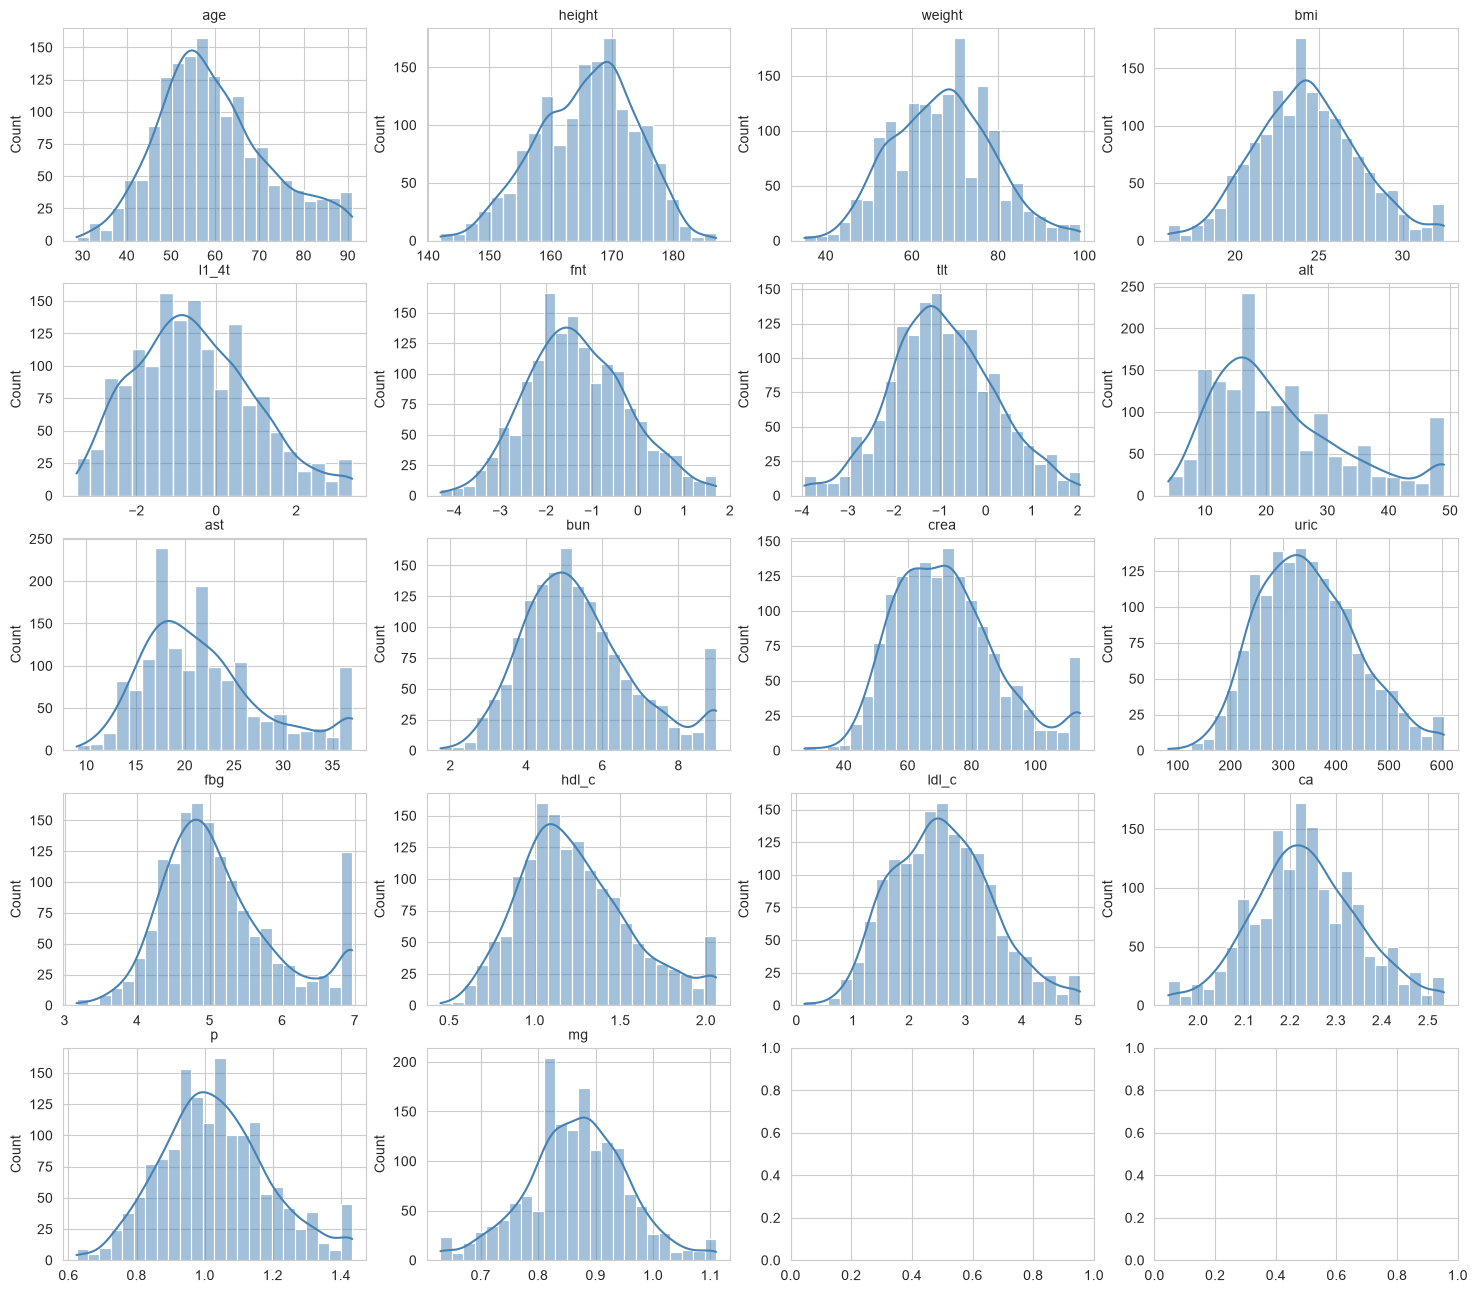

In [14]:

from sklearn.preprocessing import StandardScaler

n = len(continuous_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.2 * nrows))
axes = axes.flatten()
for i, c in enumerate(continuous_cols):
    sns.histplot(df[c], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(c, fontsize=10)
    axes[i].set_xlabel("")
plt.show()






C:\Users\Dell\AppData\Local\Temp\ipykernel_21992\1751752850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='op', y=c, data=df, ax=axes[i], palette="Set2")
C:\Users\Dell\AppData\Local\Temp\ipykernel_21992\1751752850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='op', y=c, data=df, ax=axes[i], palette="Set2")
C:\Users\Dell\AppData\Local\Temp\ipykernel_21992\1751752850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='op', y=c, data=df, ax=axes[i], palette="Set2")
C:\Users\Dell\AppData\Local\Temp\ipykernel_21992\1751752850.p

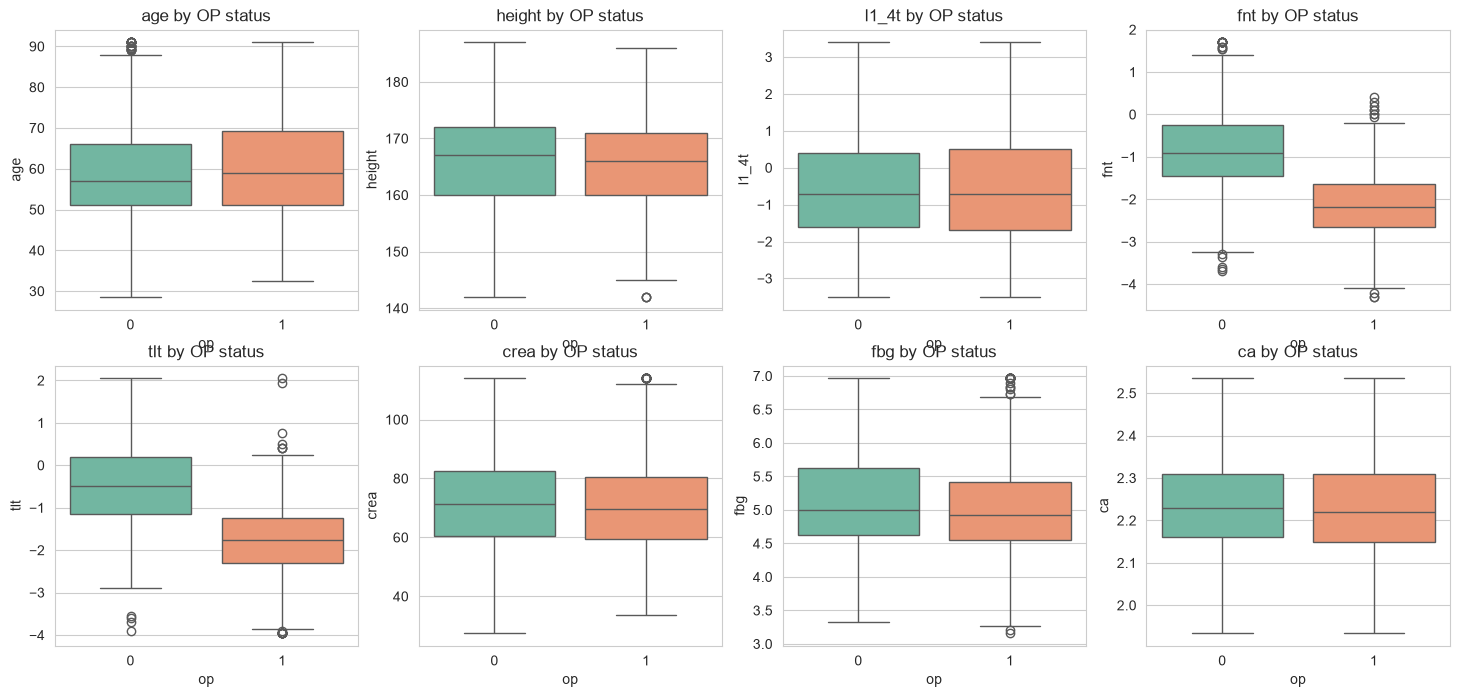

In [15]:
key_markers = ['age', 'height','l1_4t', 'fnt', 'tlt', 'crea', 'fbg', 'ca']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, c in enumerate(key_markers):
    sns.boxplot(x='op', y=c, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{c} by OP status")
plt.show()


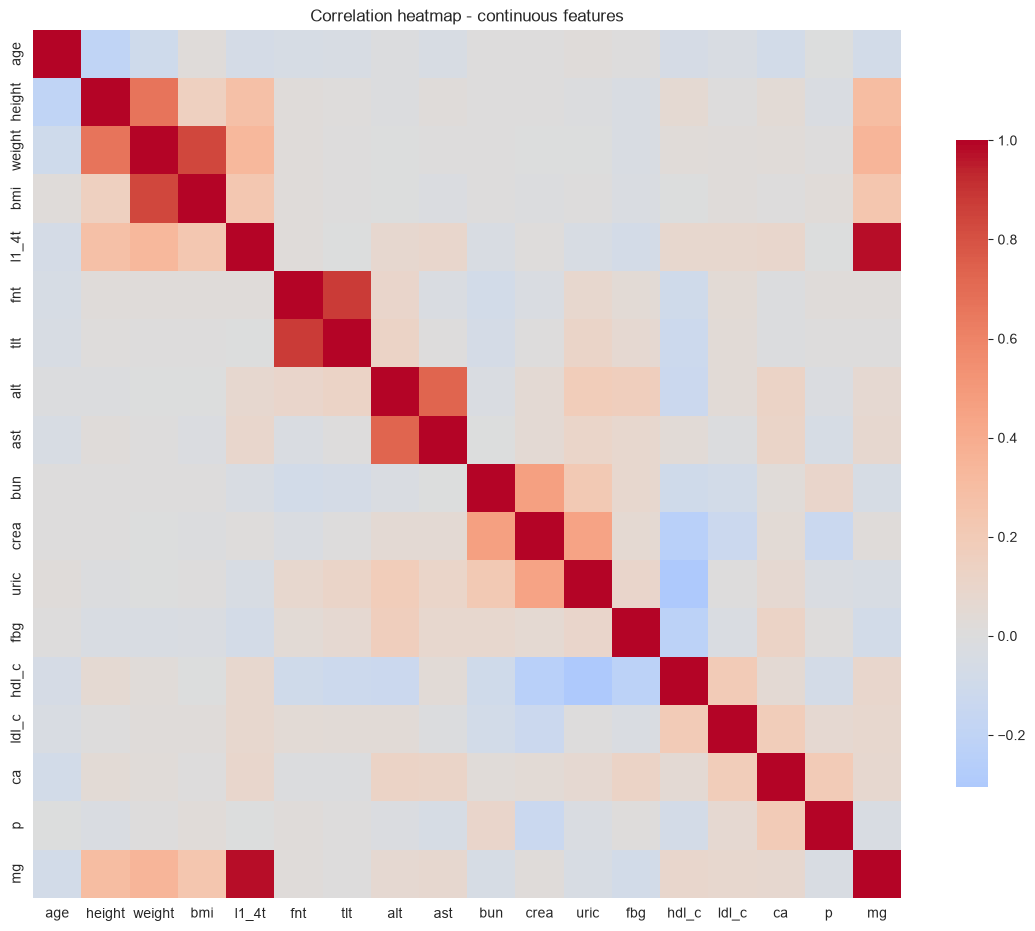

In [16]:

corr = df[continuous_cols].corr(method="pearson")

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap - continuous features")
plt.show()



In [17]:

pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))
pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr"]) \
             .sort_values("corr", key=abs, ascending=False)
print(pairs_df.to_string(index=False) if not pairs_df.empty else "None found")


print("\n=== Correlation of continuous features with OP and Fracture ===")
target_corr = df[continuous_cols + ['op', 'fracture']].corr()[['op', 'fracture']] \
                .drop(['op', 'fracture'], errors='ignore')
target_corr = target_corr.reindex(target_corr['op'].abs().sort_values(ascending=False).index)
print(target_corr.round(3))



feature_1 feature_2  corr
    l1_4t        mg 0.979
      fnt       tlt 0.882
   weight       bmi 0.834
      alt       ast 0.725

=== Correlation of continuous features with OP and Fracture ===
           op  fracture
fnt    -0.570    -0.040
tlt    -0.567    -0.089
alt    -0.153     0.001
fbg    -0.077    -0.006
bun     0.074     0.036
uric   -0.072    -0.023
ldl_c  -0.069    -0.017
hdl_c   0.060     0.032
age     0.047    -0.024
ast    -0.036     0.018
ca     -0.027    -0.022
p      -0.020     0.001
crea   -0.014     0.016
height  0.007    -0.000
weight  0.006     0.007
l1_4t   0.005     0.012
mg      0.005     0.013
bmi     0.003     0.007


In [18]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[continuous_cols] = scaler.fit_transform(df[continuous_cols])





In [19]:
df['op'].value_counts()

op
0    968
1    568
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFECV
from sklearn.ensemble import RandomForestClassifier

In [21]:
 
TARGET = "op"
 
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [22]:
# Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
kept_cols = X.columns[vt.get_support()]
X = X[kept_cols]

# Correlation Removal
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
target_corr = X.corrwith(y).abs()

to_drop = set()

for col in upper.columns:
    for row in upper.index:
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85:
            drop_col = col if target_corr[col] < target_corr[row] else row
            to_drop.add(drop_col)

X = X.drop(columns=list(to_drop))

# Scaling (only if needed)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# RFECV
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rfecv = RFECV(
    estimator=rf_selector,
    step=1,
    cv=cv,
    scoring="roc_auc",
    min_features_to_select=10
)

rfecv.fit(X_scaled, y)

final_features = list(X_scaled.columns[rfecv.support_])

X_final = X_scaled[final_features]

print("Final Features:", final_features)

d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarnin

Final Features: ['gender', 'age', 'height', 'weight', 'bmi', 'l1_4t', 'fnt', 'alt', 'ast', 'bun', 'crea', 'uric', 'fbg', 'hdl_c', 'ldl_c', 'ca', 'p', 'calsium', 'calcitriol', 'bisphosphonate', 'calcitonin', 'htn', 'copd', 'dm', 'hyperlipidaemia', 'hyperuricemia', 'as', 'vt', 'vd', 'cad', 'ckd', 'fracture', 'smoking', 'drinking']


d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarnin

In [23]:


rf_selector.fit(X_scaled, y)

importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_scaled.columns
).sort_values(ascending=False)

print(importance)

d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarnin

fnt                0.278528
calcitriol         0.041309
uric               0.041216
alt                0.041135
bun                0.039886
crea               0.039465
fbg                0.038589
ldl_c              0.037401
l1_4t              0.036711
age                0.036019
hdl_c              0.035913
bmi                0.034183
ca                 0.034108
p                  0.033942
height             0.032510
ast                0.031368
weight             0.030220
calsium            0.023044
calcitonin         0.021709
as                 0.012888
bisphosphonate     0.011481
copd               0.009704
cad                0.008867
htn                0.006821
hyperlipidaemia    0.006694
drinking           0.006270
dm                 0.005347
gender             0.005080
smoking            0.004815
hyperuricemia      0.004783
ckd                0.003387
vd                 0.003277
vt                 0.001803
fracture           0.001526
dtype: float64


d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarnin

In [24]:
final_features = importance.head(20).index.tolist()

X_final = X_scaled[final_features]
X_final

,fnt,calcitriol,uric,alt,bun,crea,fbg,ldl_c,l1_4t,age,hdl_c,bmi,ca,p,height,ast,weight,calsium,calcitonin,as
0,-1.496136,2.200069,-0.867769,-0.471769,1.817521,0.756738,-0.734470,-0.606674,-1.232902,0.163434,-0.238141,-2.152705,-0.715718,0.050397,-0.228514,-0.137645,-1.726218,2.407584,-0.246523,0.578353
1,0.003171,-0.454531,1.251547,1.066034,1.509234,0.768806,-1.543620,-0.278912,1.250011,-0.379565,-0.055138,-1.174114,-0.715718,0.488687,-0.478699,0.492632,-1.125878,2.407584,-0.246523,0.578353
2,-2.313940,2.200069,1.389948,-1.014523,-0.166238,0.237813,-0.599612,-1.070061,0.243425,-1.245215,0.920883,-1.010790,-0.460381,0.426074,-0.728885,-0.137645,-1.125878,2.407584,4.056420,0.578353
3,-0.769199,-0.454531,1.326558,-1.638690,2.413989,1.915268,2.073034,-1.363916,-1.165796,0.383781,-0.939656,-0.209253,0.986528,-1.014024,-0.979071,0.965341,-0.697064,-0.415354,4.056420,0.578353
4,-0.542032,2.200069,0.869099,0.885116,-0.863234,0.008521,-0.096958,-0.844018,-0.226316,2.256734,0.036364,-0.878233,-2.162627,-0.638346,0.146765,-0.452784,-0.611301,2.407584,-0.246523,0.578353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1531,-0.905500,-0.454531,1.319163,-1.195441,-0.796216,0.732602,-0.391194,0.173172,-0.964479,-0.694346,-0.512647,-0.394519,-0.375268,-0.888798,-0.728885,-0.925493,-0.697064,-0.415354,-0.246523,-1.729049
1532,1.139009,-0.454531,-0.077515,0.070985,-0.079114,-0.208704,-0.832549,2.343179,-0.561844,-0.694346,0.524374,-0.312543,0.135405,-0.450507,0.146765,0.019924,-0.182487,-0.415354,-0.246523,0.578353
1533,0.321206,-0.454531,0.715908,0.251903,0.845747,1.360139,-0.354415,0.489632,1.451329,-1.040606,-1.031158,0.047351,0.050293,-0.638346,0.271858,-0.295215,0.160564,-0.415354,-0.246523,0.578353
1534,1.956813,-0.454531,-1.878829,-0.109933,1.221053,-1.602560,-1.212604,1.020831,-0.427633,-0.379565,2.293412,-0.454385,0.305630,0.238236,1.147509,-0.295215,0.246327,-0.415354,-0.246523,-1.729049


In [25]:
APPLY_SMOTE = True
 
if APPLY_SMOTE:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=RANDOM_STATE)
    X_final, y = smote.fit_resample(X_final, y)
    print("After SMOTE, class counts:", y.value_counts().to_dict())
 

After SMOTE, class counts: {1: 968, 0: 968}


In [26]:
df['op'].value_counts()

op
0    968
1    568
Name: count, dtype: int64

In [27]:
out = X_final.copy()
out[TARGET] = y.values

out.to_csv("cleaned_dataset.csv", index=False)

In [28]:
 
joblib.dump(scaler, "scaler.pkl")                    
joblib.dump(final_features, "final_features.pkl")    


['final_features.pkl']